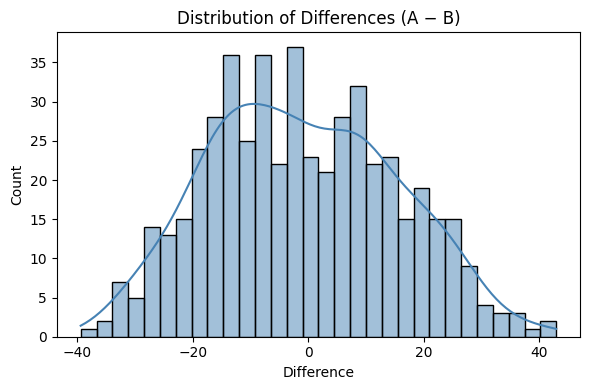

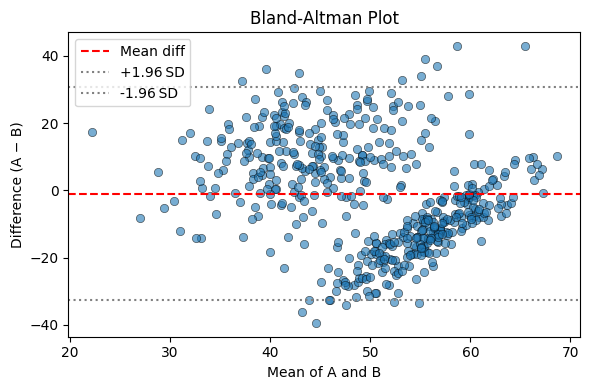

Sample size (n): 500
Mean difference (A‑B): -0.9765
t‑based 95 % CI: [-2.3963, 0.4432]
Bootstrap 95 % CI: [-2.3277, 0.4793]
Cohen's d (paired): -0.060
Cliff's delta: -0.091
Shapiro‑Wilk p (diff): 0.0018
Paired t‑test: t = -1.351, p = 0.17718
Wilcoxon signed‑rank: W = 57606.000, p = 0.12048
Permutation test p ≈ 0.18348
Proportional bias slope: -0.5197, p = 0.0000
Result description: Columns A and B do not differ significantly (α=0.05)
No


In [1]:
# Refactored analysis for columns A and B in input_data/data.csv
# -------------------------------------------------------------
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Paths ----------
INPUT_PATH = Path("input_data/data.csv")
OUT_DIR = Path("/display_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load & validate ----------
df_raw = pd.read_csv(INPUT_PATH)
df = df_raw[["A", "B"]].apply(pd.to_numeric, errors="coerce").dropna()
n = len(df)
if n == 0:
    raise SystemExit("No complete numeric (A,B) pairs found.")

a = df["A"].to_numpy()
b = df["B"].to_numpy()
diff = a - b

# ---------- Descriptive stats ----------
mean_diff = diff.mean()
sd_diff = diff.std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

# t‑based 95 % CI
dfree = n - 1
t_crit = stats.t.ppf(0.975, dfree)
ci_low_t = mean_diff - t_crit * se_diff
ci_high_t = mean_diff + t_crit * se_diff

# ---------- Bootstrap CI ----------
def bootstrap_ci(x, func=np.mean, n_boot=5000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    boot = func(x[idx], axis=1) if func is np.mean else np.apply_along_axis(lambda r: func(x[r]), 1, idx)
    lo = np.percentile(boot, 100 * (alpha / 2))
    hi = np.percentile(boot, 100 * (1 - alpha / 2))
    return lo, hi

ci_low_boot, ci_high_boot = bootstrap_ci(diff)

# ---------- Normality ----------
shapiro_p = None
if 3 <= n <= 5000:
    _, shapiro_p = stats.shapiro(diff)

# ---------- Paired tests ----------
tt_stat, tt_p = stats.ttest_rel(a, b, nan_policy="raise")
try:
    wil_stat, wil_p = stats.wilcoxon(diff, zero_method="wilcox", correction=False)
except ValueError:
    wil_stat, wil_p = np.nan, 1.0

def paired_permutation_test(a, b, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    obs = np.mean(a - b)
    diffs = a - b
    signs = rng.choice([1, -1], size=(n_perm, len(diffs)))
    perm_means = (signs * diffs).mean(axis=1)
    p = (np.abs(perm_means) >= np.abs(obs)).sum()
    return obs, (p + 1) / (n_perm + 1)

perm_stat, perm_p = paired_permutation_test(a, b)

# ---------- Effect sizes ----------
cohens_d = mean_diff / sd_diff if sd_diff != 0 else np.nan

def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    greater = np.sum(x[:, None] > y)
    lesser = np.sum(x[:, None] < y)
    return (greater - lesser) / (nx * ny)

cliff_delta = cliffs_delta(a, b)

# ---------- Proportional bias ----------
mean_vals = (a + b) / 2
slope, intercept, r_val, p_slope, _ = stats.linregress(mean_vals, diff)

# ---------- Plots ----------
# Histogram / KDE of differences
hist_png = OUT_DIR / "diff_hist.png"
hist_svg = OUT_DIR / "diff_hist.svg"
plt.figure(figsize=(6, 4))
sns.histplot(diff, kde=True, bins=30, color="steelblue")
plt.title("Distribution of Differences (A − B)")
plt.xlabel("Difference")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(hist_png, dpi=150)
plt.savefig(hist_svg)
plt.show()

# Bland‑Altman plot
ba_png = OUT_DIR / "bland_altman.png"
ba_svg = OUT_DIR / "bland_altman.svg"
loa_upper = mean_diff + 1.96 * sd_diff
loa_lower = mean_diff - 1.96 * sd_diff
plt.figure(figsize=(6, 4))
plt.scatter(mean_vals, diff, alpha=0.6, linewidths=0.5, edgecolors="k")
plt.axhline(mean_diff, color="red", linestyle="--", label="Mean diff")
plt.axhline(loa_upper, color="gray", linestyle=":", label="+1.96 SD")
plt.axhline(loa_lower, color="gray", linestyle=":", label="‑1.96 SD")
plt.title("Bland‑Altman Plot")
plt.xlabel("Mean of A and B")
plt.ylabel("Difference (A − B)")
plt.legend()
plt.tight_layout()
plt.savefig(ba_png, dpi=150)
plt.savefig(ba_svg)
plt.show()

# ---------- Reporting ----------
alpha = 0.05
significant = tt_p < alpha  # final decision based on paired t‑test

print(f"Sample size (n): {n}")
print(f"Mean difference (A‑B): {mean_diff:.4f}")
print(f"t‑based 95 % CI: [{ci_low_t:.4f}, {ci_high_t:.4f}]")
print(f"Bootstrap 95 % CI: [{ci_low_boot:.4f}, {ci_high_boot:.4f}]")
print(f"Cohen's d (paired): {cohens_d:.3f}")
print(f"Cliff's delta: {cliff_delta:.3f}")
if shapiro_p is not None:
    print(f"Shapiro‑Wilk p (diff): {shapiro_p:.4f}")
print(f"Paired t‑test: t = {tt_stat:.3f}, p = {tt_p:.5f}")
print(f"Wilcoxon signed‑rank: W = {wil_stat:.3f}, p = {wil_p:.5f}")
print(f"Permutation test p ≈ {perm_p:.5f}")
print(f"Proportional bias slope: {slope:.4f}, p = {p_slope:.4f}")
print(f"Result description: Columns A and B {'differ significantly' if significant else 'do not differ significantly'} (α={alpha})")
print("Yes" if significant else "No")   # final result only

# ---------- JSON report ----------
report = {
    "final_verdict": "Yes" if significant else "No",
    "test_used": "paired t-test",
    "n": int(n),
    "mean_difference": float(mean_diff),
    "ci_t": [float(ci_low_t), float(ci_high_t)],
    "ci_bootstrap": [float(ci_low_boot), float(ci_high_boot)],
    "cohens_d": None if np.isnan(cohens_d) else float(cohens_d),
    "cliffs_delta": float(cliff_delta),
    "shapiro_p": None if shapiro_p is None else float(shapiro_p),
    "tt_p": float(tt_p),
    "wilcoxon_p": float(wil_p),
    "permutation_p": float(perm_p),
    "proportional_bias": {
        "slope": float(slope),
        "p_value": float(p_slope)
    },
    "plots": {
        "diff_hist_png": str(hist_png),
        "diff_hist_svg": str(hist_svg),
        "bland_altman_png": str(ba_png),
        "bland_altman_svg": str(ba_svg)
    }
}
with open(OUT_DIR / "final_result.json", "w") as fp:
    json.dump(report, fp, indent=2)
